## 1. Summarizing results from .txt files

In [36]:
# Text File Data Extraction to Pandas DataFrame

import pandas as pd
import re
import os
from pathlib import Path
from typing import List, Union

# Define extraction patterns and column mappings
EXTRACTION_PATTERNS = [
    {
        'pattern': r"Target Class:\s*\[(.*?)\]",
        'column': 'Tumor type',
        'description': 'Extract tumor type from Target Class'
    },
    {
        'pattern': r"Best parameters: \{[^}]*'C': ([^,}]+)",
        'column': 'C',
        'description': 'Extract C parameter from Best parameters',
        'convert_type': float
    },
    {
        'pattern': r"Best parameters: \{[^}]*'l1_ratio': ([^,}]+)",
        'column': 'l1_ratio',
        'description': 'Extract l1_ratio from Best parameters',
        'convert_type': float
    },
    {
        'pattern': r"Number of significant proteins: (\d+)",
        'column': 'Proteins selected',
        'description': 'Extract number of significant proteins',
        'convert_type': int
    },
    {
        'pattern': r"Selected hyperparameter C: ([^\s;]+)",
        'column': 'Ridge HP',
        'description': 'Extract Ridge hyperparameter C',
        'convert_type': float
    },
    {
        'pattern': r"Train MCC Score: ([\d\.]+ ± [\d\.]+)",
        'column': 'MCC Train',
        'description': 'Extract Train MCC Score with standard deviation'
    },
    {
        'pattern': r"MCC test: ([\d\.]+)",
        'column': 'MCC Test',
        'description': 'Extract MCC test score',
        'convert_type': float
    },
    {
        'pattern': r"Confusion Matrix:\s+TN \| FP\s+\[\[(\d+)\s+(\d+)\]\s+\[\s*(\d+)\s+(\d+)\]\]\s+FN \| TP",
        'column': 'TN',
        'description': 'Extract True Negatives from confusion matrix',
        'convert_type': int,
        'group': 1  # First capture group
    },
    {
        'pattern': r"Confusion Matrix:\s+TN \| FP\s+\[\[(\d+)\s+(\d+)\]\s+\[\s*(\d+)\s+(\d+)\]\]\s+FN \| TP",
        'column': 'FP',
        'description': 'Extract False Positives from confusion matrix',
        'convert_type': int,
        'group': 2  # Second capture group
    },
    {
        'pattern': r"Confusion Matrix:\s+TN \| FP\s+\[\[(\d+)\s+(\d+)\]\s+\[\s*(\d+)\s+(\d+)\]\]\s+FN \| TP",
        'column': 'FN',
        'description': 'Extract False Negatives from confusion matrix',
        'convert_type': int,
        'group': 3  # Third capture group
    },
    {
        'pattern': r"Confusion Matrix:\s+TN \| FP\s+\[\[(\d+)\s+(\d+)\]\s+\[\s*(\d+)\s+(\d+)\]\]\s+FN \| TP",
        'column': 'TP',
        'description': 'Extract True Positives from confusion matrix',
        'convert_type': int,
        'group': 4  # Fourth capture group
    }
]

def extract_data_from_text(text, patterns):
    """
    Extract data from text using defined patterns

    Args:
        text (str): Input text to process
        patterns (list): List of pattern dictionaries

    Returns:
        dict: Extracted data with column names as keys
    """
    extracted_data = {}

    for pattern_info in patterns:
        pattern = pattern_info['pattern']
        column = pattern_info['column']
        convert_type = pattern_info.get('convert_type', str)

        # In the extract_data_from_text function, modify the matching section:
        match = re.search(pattern, text)
        if match:
            group_num = pattern_info.get('group', 1)  # Default to group 1
            value = match.group(group_num).strip()

            # Convert type if specified
            if convert_type != str:
                try:
                    value = convert_type(value)
                except (ValueError, TypeError):
                    print(f"Warning: Could not convert '{value}' to {convert_type} for column '{column}'")

            extracted_data[column] = value
        else:
            extracted_data[column] = None
            print(f"Warning: Pattern for '{column}' not found in text")

    return extracted_data

def process_single_file(file_path, patterns):
    """
    Process a single text file and extract data

    Args:
        file_path (str): Path to the text file
        patterns (list): List of extraction patterns

    Returns:
        dict: Extracted data from the file
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()

        print(f"Processing file: {file_path}")
        extracted_data = extract_data_from_text(text, patterns)

        # Add filename for reference
        extracted_data['Source_File'] = os.path.basename(file_path)

        return extracted_data

    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found")
        return None
    except Exception as e:
        print(f"Error processing file '{file_path}': {str(e)}")
        return None

def process_multiple_files(file_paths, patterns):
    """
    Process multiple text files and combine into DataFrame

    Args:
        file_paths (list): List of file paths to process
        patterns (list): List of extraction patterns

    Returns:
        pandas.DataFrame: Combined data from all files
    """
    all_data = []

    for file_path in file_paths:
        file_data = process_single_file(file_path, patterns)
        if file_data:
            all_data.append(file_data)

    if all_data:
        df = pd.DataFrame(all_data)
        return df
    else:
        print("No data extracted from any files")
        return pd.DataFrame()


# Process files from directory
def collect_classifier_output_files(
    main_folder: Union[str, Path],
    pattern: str = "classifier_output_*.txt",
    recursive: bool = False,
    require_subfolder: bool = True,
    sort: bool = True,
) -> List[Path]:
    """
    Collect classifier output .txt files from subfolders of a main folder.

    Example expected structure:
      -data
        --BRCA_2026_results
          ---classifier_output_202602.txt
        --CHDM_2026_results
          ---classifier_output_202605.txt

    Args:
        main_folder: Path to the main folder containing result subfolders.
        pattern: Glob pattern for the files to collect.
        recursive: If True, search recursively under main_folder; if False,
                   only search one level down (i.e., inside each child directory).
        require_subfolder: If True and recursive=False, only collect from
                           subdirectories (not from main_folder itself).
        sort: If True, sort returned paths for stable ordering.

    Returns:
        List[Path]: List of matched file paths.
    """
    main_folder = Path(main_folder)

    if not main_folder.exists():
        raise FileNotFoundError(f"Main folder does not exist: {main_folder}")
    if not main_folder.is_dir():
        raise NotADirectoryError(f"Main folder is not a directory: {main_folder}")

    matched: List[Path] = []

    if recursive:
        matched = [p for p in main_folder.rglob(pattern) if p.is_file()]
    else:
        # One-level-down search: each immediate child directory
        subdirs = [d for d in main_folder.iterdir() if d.is_dir()]

        for subdir in subdirs:
            matched.extend([p for p in subdir.glob(pattern) if p.is_file()])

        # Optionally include matches directly under main_folder as well
        if not require_subfolder:
            matched.extend([p for p in main_folder.glob(pattern) if p.is_file()])

    if sort:
        matched = sorted(matched)

    return matched

# Method 1: Process files from a directory
def process_files_from_directory(directory_path, file_extension='.txt'):
    """
    Process all files with specified extension from a directory
    """
    directory = Path(directory_path)
    if not directory.exists():
        print(f"Directory '{directory_path}' does not exist")
        return pd.DataFrame()

    file_paths = list(directory.glob(f'*{file_extension}'))
    if not file_paths:
        print(f"No {file_extension} files found in '{directory_path}'")
        return pd.DataFrame()

    print(f"Found {len(file_paths)} {file_extension} files")
    return process_multiple_files(file_paths, EXTRACTION_PATTERNS)

# Method 2: Process specific files
def process_specific_files(file_list):
    """
    Process a specific list of files
    """
    return process_multiple_files(file_list, EXTRACTION_PATTERNS)

def parse_and_sort_mcc(results_summary: pd.DataFrame) -> pd.DataFrame:
    df = results_summary.copy()
    df[['MCC_CV', 'std']] = df['MCC Train'].str.split(' ± ', expand=True)
    df['MCC_CV'] = pd.to_numeric(df['MCC_CV'])
    df['std'] = pd.to_numeric(df['std'])
    df = df.sort_values(['MCC Test'], ascending=[False])
    return df

In [37]:
main_results_dir = Path("/home/lestrada/projects/ProDICT/data/") # Specify directory where folders with results are stored

In [38]:
# Processing .txt files from summary results
file_paths = collect_classifier_output_files(main_results_dir) # Collecting txt files with logs of results
results_summary = process_multiple_files(file_paths, EXTRACTION_PATTERNS) # Generating summary table
results_summary = parse_and_sort_mcc(results_summary)

No data extracted from any files


KeyError: 'MCC Train'

In [8]:
results_summary

,Tumor type,C,l1_ratio,Proteins selected,Ridge HP,MCC Train,MCC Test,TN,FP,FN,TP,Source_File,MCC_CV,std
43,'THYM',10.0,0.3,318,0.1,1.0000 ± 0.0000,1.000000,386.0,0.0,0.0,2.0,classifier_output_20260203_112759.txt,1.0000,0.0000
40,'SFT',0.1,0.3,11,0.1,1.0000 ± 0.0000,1.000000,451.0,0.0,0.0,15.0,classifier_output_20260203_035016.txt,1.0000,0.0000
12,'DFSP',1.0,0.3,75,0.1,1.0000 ± 0.0000,1.000000,463.0,0.0,0.0,3.0,classifier_output_20260131_142724.txt,1.0000,0.0000
13,'DIFG',0.1,0.3,4,10.0,0.9504 ± 0.0689,1.000000,460.0,0.0,0.0,6.0,classifier_output_20260131_163805.txt,0.9504,0.0689
14,'DSRCT',10.0,0.3,372,0.1,1.0000 ± 0.0000,1.000000,459.0,0.0,0.0,7.0,classifier_output_20260131_191752.txt,1.0000,0.0000
20,'GIST',10.0,0.5,208,10.0,0.7565 ± 0.1140,1.000000,384.0,0.0,0.0,4.0,classifier_output_20260201_083606.txt,0.7565,0.1140
7,'CHDM',10.0,0.5,215,0.1,0.9881 ± 0.0168,0.979468,440.0,0.0,1.0,25.0,classifier_output_20260131_042541.txt,0.9881,0.0168
0,'ACC',10.0,0.3,316,0.1,0.9759 ± 0.0330,0.952417,455.0,0.0,1.0,10.0,classifier_output_20260130_111319.txt,0.9759,0.0330
3,'ARMS',10.0,0.3,479,0.1,0.9707 ± 0.0326,0.920869,452.0,1.0,1.0,12.0,classifier_output_20260130_191800.txt,0.9707,0.0326
42,'THYC',1.0,0.3,65,10.0,0.7976 ± 0.1776,0.893262,383.0,1.0,0.0,4.0,classifier_output_20260203_091531.txt,0.7976,0.1776


#### Compariosn of different apporaches for models

In [41]:
main_results_dir_0 = Path("/home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd")
file_paths_0 = collect_classifier_output_files(main_results_dir_0)
results_summary_0 = process_multiple_files(file_paths_0, EXTRACTION_PATTERNS)
results_summary_0 = parse_and_sort_mcc(results_summary_0)


Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ACC_260124_results/classifier_output_20260124_143916.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ACYC_260124_results/classifier_output_20260124_150330.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ACYC_260126_results/classifier_output_20260126_162101.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ANGS_260124_results/classifier_output_20260124_154841.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ARMS_260124_results/classifier_output_20260124_155335.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/ASPS_260124_results/classifier_output_20260124_165856.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/BA_ANGS_260124_results/classifier_output_20260124_175652.txt
Processing file: /home/lestrada/projects/ProDICT/data/0_run_mwu_cliffd/BRCA_260124_results/clas

In [ ]:
results_summary_0.head()

In [42]:
main_results_dir_1 = Path("/home/lestrada/projects/ProDICT/data/1_run_mwu")
file_paths_1 = collect_classifier_output_files(main_results_dir_1)
results_summary_1 = process_multiple_files(file_paths_1, EXTRACTION_PATTERNS)
results_summary_1 = parse_and_sort_mcc(results_summary_1)


Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/ACC_260126_results/classifier_output_20260126_164838.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/ACYC_260126_results/classifier_output_20260126_180405.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/ANGS_260126_results/classifier_output_20260126_200721.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/ARMS_260126_results/classifier_output_20260126_201725.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/ASPS_260126_results/classifier_output_20260126_231610.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/BA_ANGS_260127_results/classifier_output_20260127_014541.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/BRCA_260127_results/classifier_output_20260127_024241.txt
Processing file: /home/lestrada/projects/ProDICT/data/1_run_mwu/CHDM_260127_results/classifier_output_20260127_043238.txt
Processing file: /home

In [43]:
results_summary_1.head()

,Tumor type,C,l1_ratio,Proteins selected,Ridge HP,MCC Train,MCC Test,TN,FP,FN,TP,Source_File,MCC_CV,std
40,'SFT',0.1,0.3,14.0,0.1,0.9950 ± 0.0133,1.000000,451.0,0.0,0.0,15.0,classifier_output_20260128_064630.txt,0.9950,0.0133
0,'ACC',10.0,0.3,115.0,0.1,0.9821 ± 0.0271,0.952417,455.0,0.0,1.0,10.0,classifier_output_20260126_164838.txt,0.9821,0.0271
14,'DSRCT',1.0,0.3,24.0,0.1,0.9698 ± 0.0398,0.934395,458.0,1.0,0.0,7.0,classifier_output_20260127_123651.txt,0.9698,0.0398
18,'ES',10.0,0.5,115.0,0.1,0.9328 ± 0.0476,0.920869,452.0,1.0,1.0,12.0,classifier_output_20260127_151352.txt,0.9328,0.0476
6,'BRCA',10.0,0.5,145.0,1.0,0.9245 ± 0.0212,0.898465,391.0,8.0,4.0,63.0,classifier_output_20260127_024241.txt,0.9245,0.0212


In [46]:
main_results_dir_2 = Path("/home/lestrada/projects/ProDICT/data/2_run_no_mwu")
file_paths_2 = collect_classifier_output_files(main_results_dir_2)
results_summary_2 = process_multiple_files(file_paths_2, EXTRACTION_PATTERNS)
results_summary_2 = parse_and_sort_mcc(results_summary_2)


Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/ACC_260130_results/classifier_output_20260130_111319.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/ACYC_260130_results/classifier_output_20260130_135459.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/ANGS_260130_results/classifier_output_20260130_152217.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/ARMS_260130_results/classifier_output_20260130_191800.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/ASPS_260130_results/classifier_output_20260130_223159.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/BA_ANGS_260131_results/classifier_output_20260131_000455.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/BRCA_260131_results/classifier_output_20260131_021341.txt
Processing file: /home/lestrada/projects/ProDICT/data/2_run_no_mwu/CHDM_260131_results/classifier_output_20260131_042541.tx

In [47]:
results_summary_2.head()

,Tumor type,C,l1_ratio,Proteins selected,Ridge HP,MCC Train,MCC Test,TN,FP,FN,TP,Source_File,MCC_CV,std
43,'THYM',10.0,0.3,318,0.1,1.0000 ± 0.0000,1.0,386.0,0.0,0.0,2.0,classifier_output_20260203_112759.txt,1.0000,0.0000
40,'SFT',0.1,0.3,11,0.1,1.0000 ± 0.0000,1.0,451.0,0.0,0.0,15.0,classifier_output_20260203_035016.txt,1.0000,0.0000
12,'DFSP',1.0,0.3,75,0.1,1.0000 ± 0.0000,1.0,463.0,0.0,0.0,3.0,classifier_output_20260131_142724.txt,1.0000,0.0000
13,'DIFG',0.1,0.3,4,10.0,0.9504 ± 0.0689,1.0,460.0,0.0,0.0,6.0,classifier_output_20260131_163805.txt,0.9504,0.0689
14,'DSRCT',10.0,0.3,372,0.1,1.0000 ± 0.0000,1.0,459.0,0.0,0.0,7.0,classifier_output_20260131_191752.txt,1.0000,0.0000


In [50]:
pd.concat([results_summary_0[['Tumor type', 'Proteins selected', 'MCC Train']].sort_values(by='Tumor type'),
results_summary_1[['Tumor type', 'Proteins selected', 'MCC Train']].sort_values(by='Tumor type'),
results_summary_2[['Tumor type', 'Proteins selected', 'MCC Train']].sort_values(by='Tumor type')], axis=1)


,Tumor type,Proteins selected,MCC Train,Tumor type,Proteins selected,MCC Train,Tumor type,Proteins selected,MCC Train
0,'ACC',9.0,0.8807 ± 0.0605,'ACC',115.0,0.9821 ± 0.0271,'ACC',316.0,0.9759 ± 0.0330
1,'ACYC',6.0,0.7499 ± 0.0726,'ACYC',7.0,0.7874 ± 0.0513,'ACYC',9.0,0.8610 ± 0.0508
3,'ANGS',NaN,None,'ARMS',361.0,0.9704 ± 0.0330,'ARMS',479.0,0.9707 ± 0.0326
4,'ARMS',5.0,0.9507 ± 0.0419,'ASPS',13.0,1.0000 ± 0.0000,'ASPS',8.0,0.9828 ± 0.0381
5,'ASPS',13.0,1.0000 ± 0.0000,"'BA', 'ANGS'",1.0,0.1246 ± 0.0417,"'BA', 'ANGS'",15.0,0.4184 ± 0.0920
6,"'BA', 'ANGS'",1.0,0.1246 ± 0.0417,'BRCA',145.0,0.9245 ± 0.0212,'BRCA',20.0,0.7561 ± 0.0334
7,'BRCA',48.0,0.8699 ± 0.0283,'CHDM',37.0,0.9469 ± 0.0486,'CHDM',215.0,0.9881 ± 0.0168
8,'CHDM',20.0,0.9400 ± 0.0583,'CHS',5.0,0.3520 ± 0.0855,'CHS',63.0,0.4304 ± 0.1888
9,'CHS',0.0,None,'COAD',2.0,0.2488 ± 0.0794,'COAD',9.0,0.3133 ± 0.0749
10,'COAD',0.0,None,"'COAD', 'READ', 'COADREAD'",6.0,0.5009 ± 0.1308,"'COAD', 'READ', 'COADREAD'",39.0,0.7520 ± 0.0757


## 2. Collecting in a dataframe Features selected for all claissifiers generated

In [ ]:
# Collecting the mall the models generated, and importing them.
import os

folder_path = "/home/lestrada/projects/ProDICT/data/1_run_mwu"
protein_dict = {}

for root, _, filenames in os.walk(folder_path):
    for filename in filenames:
        if filename.endswith("_selected_features.txt"):
            filepath = os.path.join(root, filename)

            with open(filepath, "r") as f:
                proteins = [line.strip() for line in f if line.strip()]

            key = filename.replace("_selected_features.txt", "")
            protein_dict[key] = proteins




In [10]:
len(protein_dict.keys())

41

## 3.Barplots

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### 3.1 Comparison of MCC Test

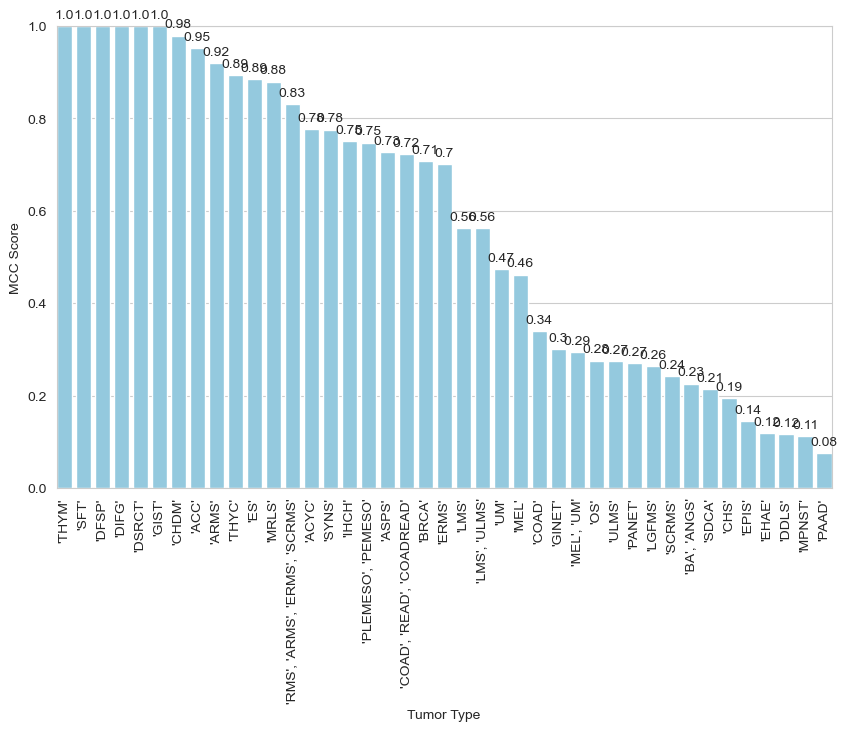

In [12]:
## BARPLOT MCC Scores
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Arial'

plt.rcParams['figure.figsize'] = (10, 6)

# Sample data
categories = results_summary['Tumor type']
values = results_summary['MCC Test']

# Create DataFrame (optional, but good practice)
df = pd.DataFrame({
    'Category': categories,
    'Values': values
})

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='Category', y='Values', color='skyblue')

# Customize the plot
plt.xlabel('Tumor Type', fontsize=10)
plt.xticks(rotation=90)
plt.ylabel('MCC Score', fontsize=10)
plt.margins(0)

# Add value labels on top of bars
for i, v in enumerate(values):
    ax.text(i, v + 0.01, str(np.round(v, decimals=2)), ha='center', va='bottom', fontweight='light')


plt.rcParams["svg.fonttype"] = "none"
plt.savefig('bar_plot.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()


### 3.2 Comparison of MCC Train vs MCC Test

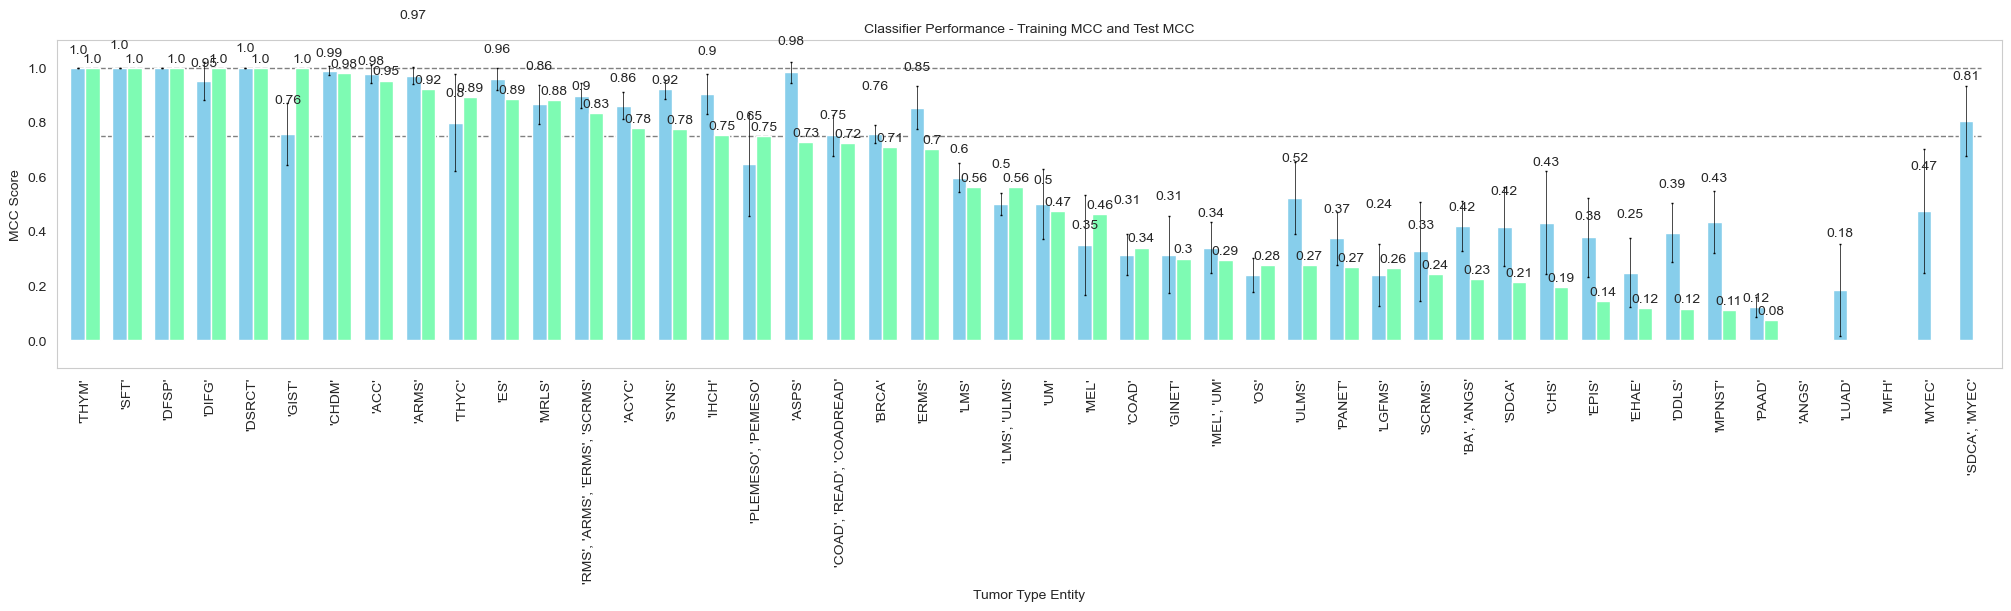

Grouped bar plot saved as 'grouped_mcc_ba r_plot.svg'


In [13]:
## MCC TRAIN - TEST

# Set the aesthetic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.figsize'] = (20, 6)

# Sample data (replace with your actual results_summary)
# Assuming results_summary is a DataFrame with 'code_oncotree', 'MCC_CV', and 'MCC_TEST'
# For demonstration, I'll create sample data
categories = results_summary['Tumor type']
mcc_data = {
    'MCC_CV': results_summary['MCC_CV'],
    'MCC_TEST': results_summary['MCC Test']
}
std_mcc_cv  = results_summary['std']


# Create figure and axis
fig, ax = plt.subplots(layout='constrained')

# Parameters for grouped bars
x = np.arange(len(categories))  # Label locations
width = 0.35  # Width of the bars (adjusted to fit two bars per category)
multiplier = 0

# Plot grouped bars
for attribute, measurement in mcc_data.items():
    offset = width * multiplier
    if attribute == 'MCC_CV':
        # Add error bars for MCC_CV
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=['skyblue'][multiplier], yerr=std_mcc_cv, error_kw={'elinewidth': 0.5, 'ecolor': 'black'} , capsize=0.5)
    else:
        # No error bars for MCC_TEST
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=['#7efbb3'])
    # Add value labels on top of bars
    for i, v in enumerate(measurement):
        ax.text(i + offset, v + 0.01 + (std_mcc_cv[i] if attribute == 'MCC_CV' else 0), str(np.round(v, 2)), ha='center', va='bottom', fontweight='light')
    multiplier += 1

# Customize the plot
ax.hlines(y=1.0, xmin=0, xmax=len(categories)-1+width, linewidth=1, color='grey',ls='--',zorder=0)
ax.hlines(y=0.75, xmin=0, xmax=len(categories)-1+width, linewidth=1, color='grey', ls = '--',zorder=0)
ax.grid(False)
ax.set_xlabel('Tumor Type Entity', fontsize=10)
ax.set_ylabel('MCC Score', fontsize=10)
ax.set_title('Classifier Performance - Training MCC and Test MCC', fontsize=10)
ax.set_xticks(x + width / 2, categories, rotation=90)
ax.set_ylim(-0.1, 1.1)  # MCC is capped at 1, so set y-limit slightly above for clarity
ax.set_xlim(-0.5, len(categories) - 0.5 + width)
# Improve layout
#plt.tight_layout()

# Export to SVG
plt.savefig('train_test_mcc_bar_plot.svg', format='svg', dpi=600, bbox_inches='tight')

# Display the plot
plt.show()

print("Grouped bar plot saved as 'grouped_mcc_ba r_plot.svg'")

### 3.3 MCC Test vs Optimized MCC Test

## 4. Confusion Matrix

In [14]:
folder_path = "/home/lestrada/projects/ProDICT/data/1_run_mwu"
test_predictions = pd.DataFrame()

for root, _, filenames in os.walk(folder_path):
    for filename in filenames:
        if filename.startswith("test_") and filename.endswith("_probabilities.xlsx"):
            filepath = os.path.join(root, filename)

            label = filename.removeprefix("test_").removesuffix("_probabilities.xlsx")
            test_predictions[label] = pd.read_excel(filepath)['Probability']
test_predictions['code_oncotree'] = pd.read_excel(filepath)['code_oncotree']

display(test_predictions.head())


,DSRCT,IHCH,COAD,LGFMS,LMS,BA_ANGS,GIST,SYNS,PAAD,MPNST,...,ANGS,DIFG,DFSP,MRLS,ARMS,COAD_READ_COADREAD,ACYC,LMS_ULMS,RMS_ARMS_ERMS_SCRMS,code_oncotree
0,0.000171,2.655672e-15,0.001191,0.084435,0.003856,0.195458,0.000649,0.000117,1.685977e-07,2.787275e-27,...,1.421566e-05,5.910078e-18,0.000006,5.353140e-09,0.000010,2.106257e-05,1.022034e-09,0.169750,2.012849e-09,BRCA
1,0.000052,9.991917e-01,0.000078,0.034200,0.035653,0.243830,0.000007,0.000290,1.728222e-06,2.877997e-04,...,4.457949e-04,1.658781e-13,0.000281,6.898179e-12,0.000183,1.354541e-01,2.577422e-06,0.178525,7.852740e-04,PANET
2,0.000210,7.259431e-15,0.992466,0.244253,0.277896,0.127349,0.000228,0.000185,5.460083e-12,1.000000e+00,...,1.335155e-05,2.253500e-16,0.000042,6.751134e-09,0.000408,1.153370e-09,3.966778e-08,0.052083,1.969764e-05,DDLS
3,0.000641,1.107313e-20,0.000009,0.357843,0.019900,0.125150,0.000002,0.173641,1.508147e-21,1.586312e-11,...,1.753295e-03,6.421334e-14,0.163978,1.022584e-02,0.000140,4.186912e-05,2.917924e-06,0.015855,4.798469e-07,VSC
4,0.000006,1.335481e-01,0.913429,0.009499,0.000029,0.070821,0.000254,0.015439,1.868129e-11,1.323389e-10,...,4.614887e-10,2.378471e-17,0.000416,6.255779e-01,0.000099,6.328457e-04,8.091105e-07,0.031272,1.247344e-10,DDLS


### 4.1 Per class Confussion Matrix

In [15]:
def per_class_confusion_matrices(
    df: pd.DataFrame,
    label_col: str = "code_oncotree",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute TP, FP, TN, FN for each class column (one-vs-rest).
    """
    results = []

    class_columns = df.columns.drop(label_col)

    for cls in class_columns:
        y_true = df[label_col] == cls
        y_pred = df[cls] > threshold

        TP = (y_pred & y_true).sum()
        FP = (y_pred & ~y_true).sum()
        FN = (~y_pred & y_true).sum()
        TN = (~y_pred & ~y_true).sum()

        results.append({
            "class": cls,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN
        })

    return pd.DataFrame(results).set_index("class")


In [16]:
per_class_confusion_matrices(test_predictions)

,TP,FP,FN,TN
class,,,,
DSRCT,7,1,0,458
IHCH,7,31,2,426
COAD,1,30,4,431
LGFMS,0,66,4,396
LMS,19,45,3,399
BA_ANGS,0,99,0,367
GIST,0,9,4,453
SYNS,20,14,3,429
PAAD,1,5,5,455


### 4.3 All Class Confussion Matrix

In [17]:
from matplotlib.colors import LinearSegmentedColormap

def column_confusion_matrix(df, true_col="code_oncotree", threshold=None):
    """
    Returns a confusion table with:
      - rows: true labels + 'Others'
      - columns: predicted classes (only your model classes)
    Counts reflect one-vs-rest positives per column (multi-hot OK).
    """
    # Classifier classes are all columns except the true label column
    classes = [c for c in df.columns if c != true_col]

    # Map true labels not in classes to 'Others'
    true_mapped = df[true_col].where(df[true_col].isin(classes), "Others")

    # Binarize predictions (if probabilities, pick a threshold; else assume 0/1)
    pred_bin = df[classes].copy()
    if threshold is not None:
        pred_bin = (pred_bin >= float(threshold)).astype(int)
    else:
        pred_bin = pred_bin.astype(int)

    # Build counts: for each class column, count positives by true_mapped
    # This yields rows (true labels incl. Others) x columns (predicted classes)
    conf = (
        pd.DataFrame(
            {cls: pred_bin.loc[pred_bin[cls] == 1].groupby(true_mapped).size()
             for cls in classes}
        )
        .reindex(index=classes + ["Others"], columns=classes, fill_value=0)
    )

    return conf

def per_column_tp_fp(conf):
    """Compute TP and FP per predicted class from the confusion table."""
    out = []
    for cls in conf.columns:
        tp = conf.loc[cls, cls] if cls in conf.index else 0
        fp = conf[cls].sum() - tp  # all other rows in that column
        out.append({"class": cls, "TP": int(tp), "FP": int(fp)})
    return pd.DataFrame(out)

def plot_row_scaled_heatmap(conf):
    """
    Compact row-scaled heatmap:
      - Each row has its own color scale
      - X labels only on top
      - Integer annotations inside cells
      - No gaps between rows
    """
    n_rows, n_cols = conf.shape
    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(n_cols*0.6, n_rows*0.6),  # reduce height per row
        sharex=True,
        gridspec_kw={'hspace':0}  # no vertical space
    )
    colormap_customization = LinearSegmentedColormap.from_list(
        "custom_blues", ["white", "skyblue"]
    )
    if n_rows == 1:
        axes = [axes]

    for i, row_label in enumerate(conf.index):
        row = conf.loc[[row_label]].astype(int)
        ax = axes[i]

        vmax_val = max(1, row.values.max())

        sns.heatmap(
            row,
            annot=True, fmt="d", cmap=colormap_customization,
            cbar=False,
            ax=ax,
            vmin=0, vmax=vmax_val,
            linewidths=0, linecolor=None,
            xticklabels=False, yticklabels=False
        )

        # Put true class label at left
        ax.set_ylabel(row_label, rotation=0, ha="right", va="center")

        # Only show x-axis labels on the very top
        if i == 0:
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
            ax.set_xticks(range(len(conf.columns)))
            ax.set_xticklabels(conf.columns, rotation=45, ha="left")
        else:
            ax.set_xticks([])

        # Remove spines (extra borders)
        for spine in ax.spines.values():
            spine.set_visible(False)
    plt.rcParams["svg.fonttype"] = "none"
    plt.subplots_adjust(hspace=0)  # extra safeguard
    plt.savefig('coeff_matrix_A.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()

In [18]:
confusion_matrix = column_confusion_matrix(test_predictions, true_col="code_oncotree", threshold=0.5)

In [20]:
confusion_matrix.fillna(value=0)

,DSRCT,IHCH,COAD,LGFMS,LMS,BA_ANGS,GIST,SYNS,PAAD,MPNST,...,ACC,ANGS,DIFG,DFSP,MRLS,ARMS,COAD_READ_COADREAD,ACYC,LMS_ULMS,RMS_ARMS_ERMS_SCRMS
code_oncotree,,,,,,,,,,,,,,,,,,,,,
DSRCT,7.0,0.0,1.0,2.0,1.0,5.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
IHCH,0.0,7.0,1.0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
COAD,0.0,1.0,1.0,2.0,0.0,0.0,2.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
LGFMS,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
LMS,0.0,0.0,3.0,2.0,19.0,1.0,0.0,0.0,0.0,4.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,21.0,0.0
BA_ANGS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GIST,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SYNS,0.0,0.0,2.0,3.0,4.0,0.0,1.0,20.0,0.0,2.0,...,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,6.0,1.0
PAAD,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


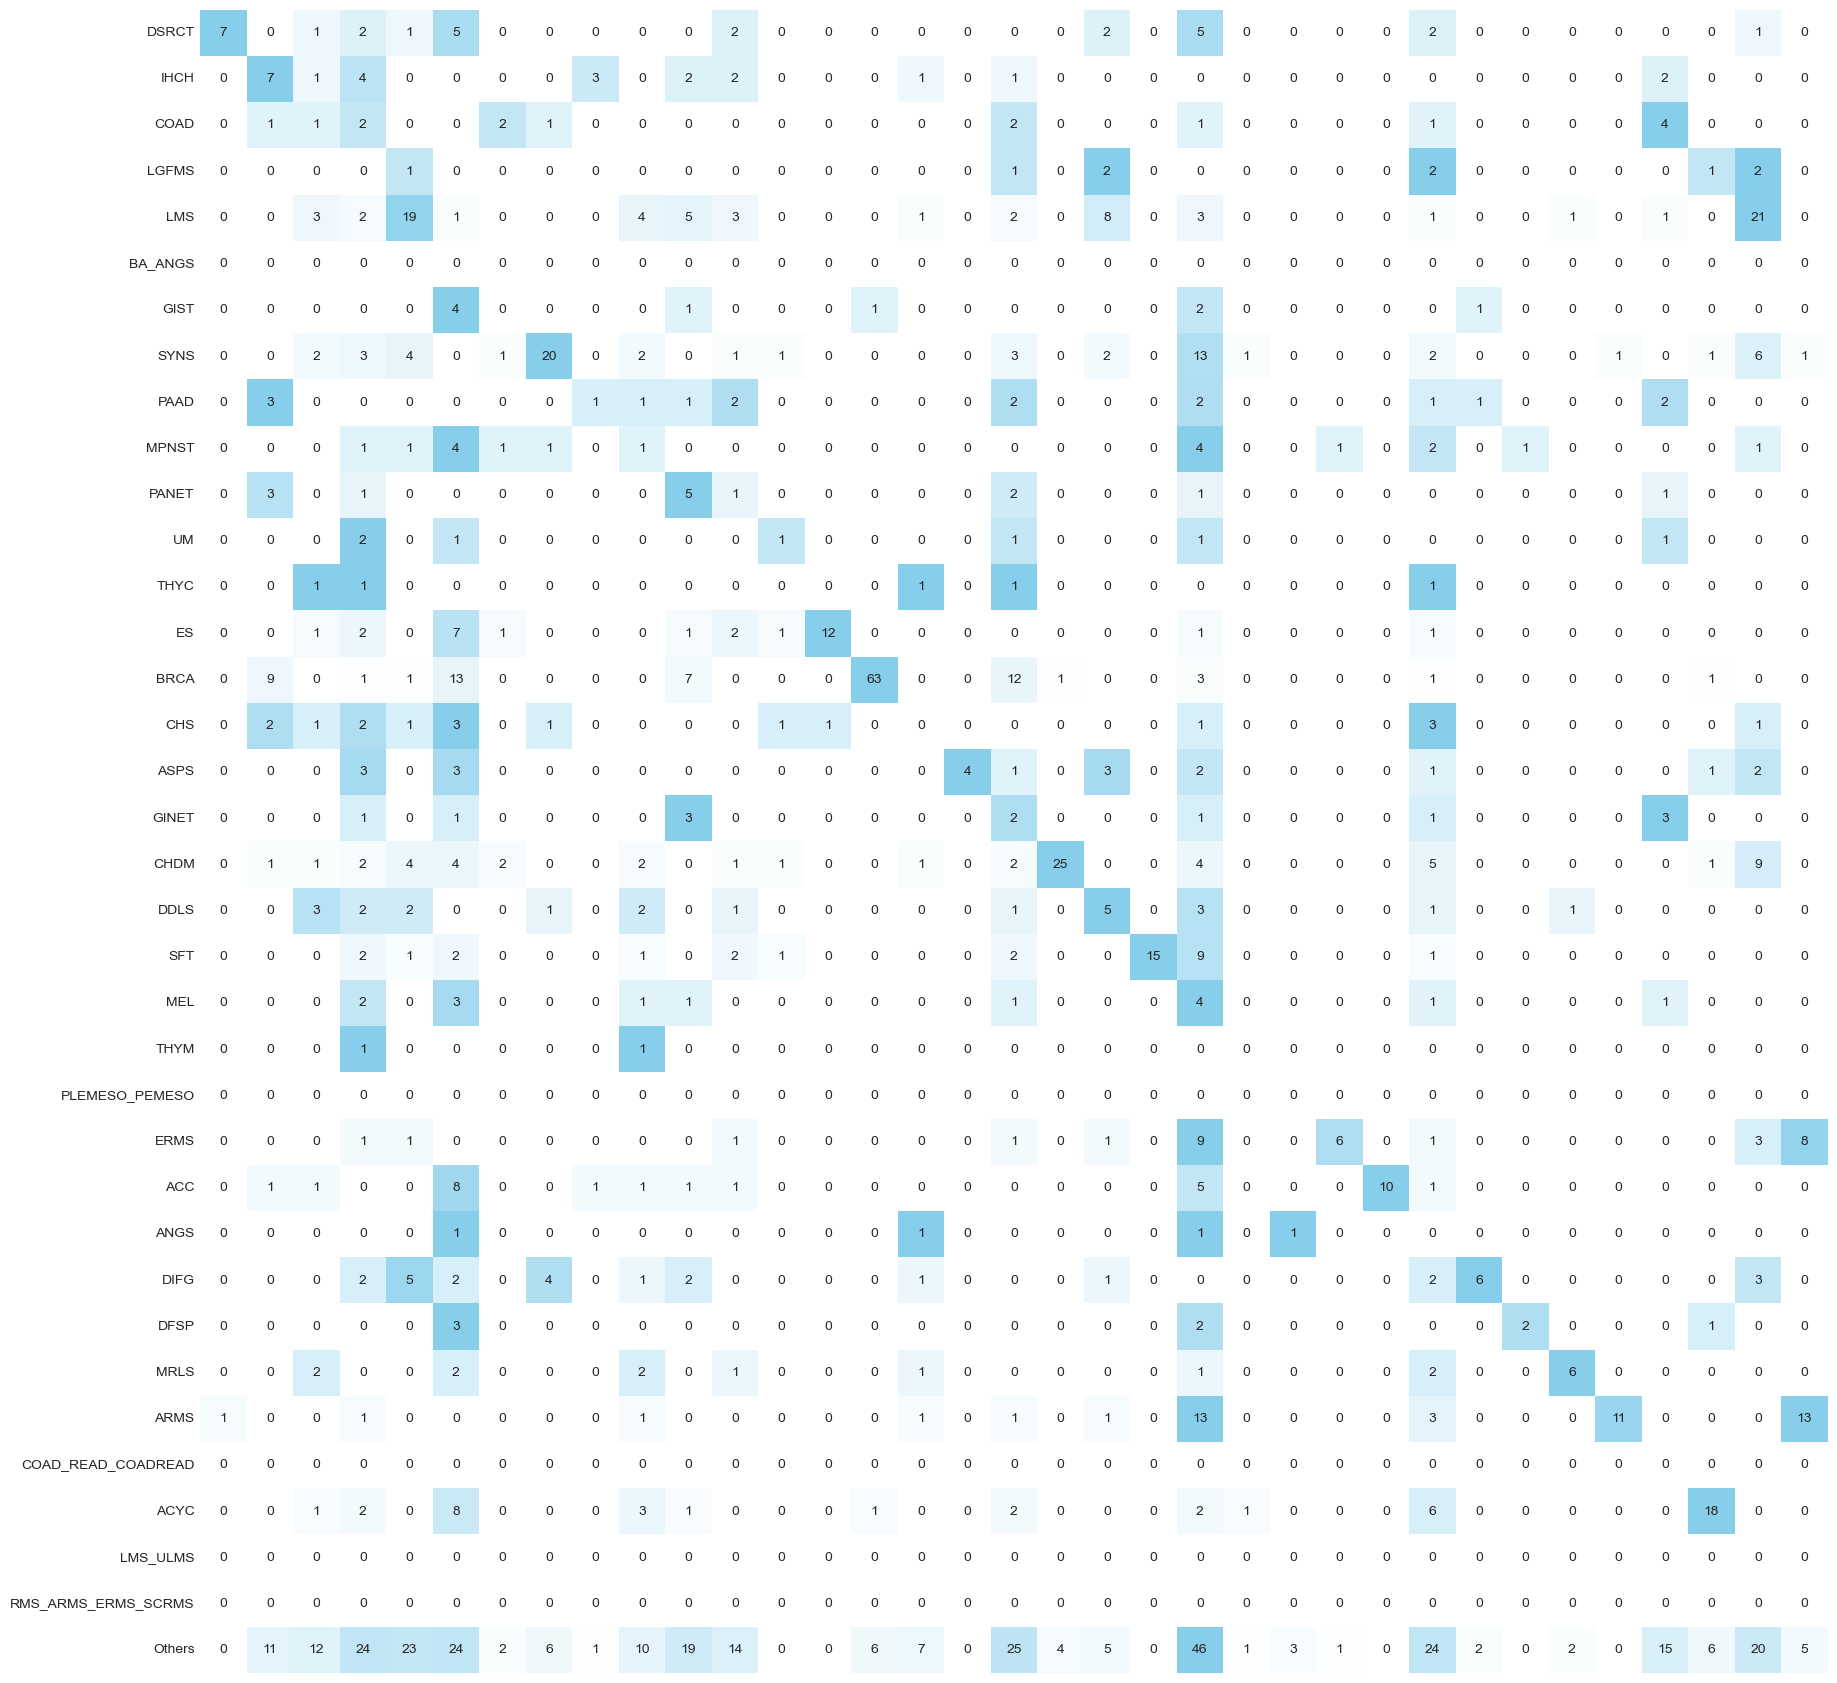

In [21]:
summary_tp_FP = per_column_tp_fp(confusion_matrix.fillna(value=0))
plot_row_scaled_heatmap(confusion_matrix.fillna(value=0))

## 5. NOS Classification

In [ ]:
import pandas as pd
import pickle
import numpy as np
import os
from pathlib import Path
import warnings
from joblib import load

def load_models_from_folder(models_folder_path):
    """
    Load all .pkl model files from a specified folder.

    Parameters:
    models_folder_path (str): Path to folder containing .pkl model files

    Returns:
    dict: Dictionary with model names as keys and loaded models as values
    """
    models = {}
    models_folder = Path(models_folder_path)


    pkl_files = list(models_folder.rglob("*model.pkl"))

    if not pkl_files:
        raise ValueError(f"No .pkl files found in {models_folder_path}")

    print(f"Found {len(pkl_files)} model files:")

    for pkl_file in pkl_files:
        try:
            model = load(pkl_file)
            models[pkl_file.stem] = model
            print(f"  ✓ Loaded: {pkl_file.name}")
        except Exception as e:
            print(f"  ✗ Failed to load {pkl_file.name}: {str(e)}")

    return models

def load_excel_data(excel_file_path, sheet_name=None):
    """
    Load data from Excel file.

    Parameters:
    excel_file_path (str): Path to Excel file
    sheet_name (str, optional): Sheet name to load. If None, loads first sheet

    Returns:
    pd.DataFrame: Loaded dataset
    """
    try:
        if sheet_name:
            df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
        else:
            df = pd.read_excel(excel_file_path)

        print(f"Dataset loaded successfully:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}")

        return df

    except Exception as e:
        raise Exception(f"Error loading Excel file: {str(e)}")

def apply_models_to_data(dataset, models, include_probabilities=True, include_predictions=True):
    """
    Apply multiple models to dataset and return predictions/probabilities.

    Parameters:
    dataset (pd.DataFrame): Input dataset with samples as rows
    models (dict): Dictionary of loaded models
    include_probabilities (bool): Whether to include probability columns
    include_predictions (bool): Whether to include prediction columns

    Returns:
    pd.DataFrame: Original dataset with added prediction columns
    """
    results_df = dataset.iloc[:,:4]

    print(f"\nApplying {len(models)} models to dataset...")

    for model_name, model in models.items():
        print(f"\nProcessing model: {model_name}")

        try:
            # Get required features for this model
            required_features = model.feature_names_in_
            print(f"  Required features: {len(required_features)} features")

            # Check if all required features are available in dataset
            missing_features = set(required_features) - set(dataset.columns)
            if missing_features:
                print(f"  ⚠️  Missing features: {missing_features}")
                print(f"  Skipping model {model_name}")
                continue

            # Filter dataset to include only required features
            model_data = dataset[required_features]

            # Check for missing values
            if model_data.isnull().any().any():
                print(f"  ⚠️  Warning: Missing values detected in required features")
                print(f"  Missing value counts:")
                missing_counts = model_data.isnull().sum()
                for feature, count in missing_counts[missing_counts > 0].items():
                    print(f"    {feature}: {count} missing values")

                # skip rows with missing values
                valid_rows = ~model_data.isnull().any(axis=1)
                model_data_clean = model_data[valid_rows]
                print(f"  Using {len(model_data_clean)} samples with complete data")
            else:
                model_data_clean = model_data
                valid_rows = pd.Series([True] * len(dataset))

            if len(model_data_clean) == 0:
                print(f"  ⚠️  No valid samples for model {model_name}")
                continue

            # Make predictions
            if include_predictions:
                predictions = model.predict(model_data_clean)
                model_name = str(model_name).removesuffix("_log_reg_ridge_model")
                pred_column = f"{model_name}"
                results_df.loc[valid_rows, pred_column] = predictions
                print(f"  ✓ Added prediction column: {pred_column}")

            # Get probabilities
            if include_probabilities:
                if hasattr(model, 'predict_proba'):
                    probabilities = model.predict_proba(model_data_clean)

                    # Handle binary vs multiclass
                    if probabilities.shape[1] == 2:
                        # Binary classification - typically use probability of positive class
                        prob_column = f"{model_name}"
                        results_df.loc[valid_rows, prob_column] = probabilities[:, 1]
                        print(f"Added probability column: {prob_column}")
                    else:
                        continue

                else:
                    print(f"Model {model_name} doesn't support probability prediction")

            print(f"  ✓ Successfully processed model {model_name}")

        except Exception as e:
            print(f"  ✗ Error processing model {model_name}: {str(e)}")

    return results_df

def predict_probs(excel_file_path, models_folder_path, output_file_path=None, sheet_name=None):
    """
    Main function to orchestrate the entire process.

    Parameters:
    excel_file_path (str): Path to Excel file with dataset
    models_folder_path (str): Path to folder containing .pkl model files
    output_file_path (str, optional): Path to save results. If None, returns DataFrame
    sheet_name (str, optional): Sheet name to load from Excel

    Returns:
    pd.DataFrame: Dataset with added prediction/probability columns
    """

    # Load dataset
    dataset = load_excel_data(excel_file_path, sheet_name)

    # Load models
    models = load_models_from_folder(models_folder_path)

    if not models:
        raise ValueError("No models specified")

    #Apply models

    results = apply_models_to_data(dataset, models)

    # Save results (optional)
    if output_file_path:
        print(f"\n4. Saving results to {output_file_path}...")
        results.to_excel(output_file_path, index=False)

    # Summary
        print(f"Original dataset shape: {dataset.shape}")
    print(f"Final dataset shape: {results.shape}")
    print(f"Models processed: {len(models)}")

    new_columns = [col for col in results.columns if col not in dataset.columns]
    print(f"New columns added: {len(new_columns)}")
    for col in new_columns:
        print(f"  - {col}")

    return results


# Additional utility functions:

def get_model_summary(models):
    """
    Print summary information about loaded models.
    """
    print("\n=== Model Summary ===")
    for name, model in models.items():
        print(f"\nModel: {name}")
        print(f"  Type: {type(model).__name__}")
        print(f"  Features required: {len(model.feature_names_in_)}")
        print(f"  Feature names: {list(model.feature_names_in_[:5])}{'...' if len(model.feature_names_in_) > 5 else ''}")
        if hasattr(model, 'classes_'):
            print(f"  Classes: {model.classes_}")

def check_feature_coverage(dataset, models):
    """
    Check which models can be applied to the dataset based on feature availability.
    """
    print("\n=== Feature Coverage Analysis ===")
    dataset_features = set(dataset.columns)

    for model_name, model in models.items():
        required_features = set(model.feature_names_in_)
        missing_features = required_features - dataset_features
        coverage = len(required_features - missing_features) / len(required_features) * 100

        print(f"\nModel: {model_name}")
        print(f"  Feature coverage: {coverage:.1f}% ({len(required_features - missing_features)}/{len(required_features)})")
        if missing_features:
            print(f"  Missing features: {missing_features}")
        else:
            print(f"  ✓ All features available")

# Quick start function for immediate use:
def quick_predict(excel_path, models_folder_path, output_path=None):
    """
    Simplified function for quick predictions.
    """
    return predict_probs(excel_path, models_folder_path, output_path)

In [32]:
models_folder = '/home/lestrada/projects/ProDICT/data/2_run_no_mwu'
NOS_output_folder = '/home/lestrada/projects/ProDICT/data/NOS_predictions/'

excel_file = "/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/LE_PROdict/paper_classifier_results/03_selected_classifiers_models/NOS_predictions/removed_samples_NOS.xlsx"
output_file = NOS_output_folder + "NOS_predictions.xlsx"


In [33]:
try:
    # Run the pipeline
    results_df = predict_probs(
        excel_file_path=excel_file,
        models_folder_path=models_folder,
        output_file_path=output_file,
        sheet_name=None  # Use None for first sheet, or specify sheet name
    )

    # Display sample results
    print(f"\nSample of results:")
    print(results_df.head())

    # Show probability columns specifically
    prob_columns = [col for col in results_df.columns if 'prob' in col.lower()]
    if prob_columns:
        print(f"\nProbability columns:")
        print(results_df[prob_columns].head())

except Exception as e:
    print(f"Error: {str(e)}")


Dataset loaded successfully:
  Shape: (206, 13073)
  Columns: ['Sample name', 'code_oncotree', 'TCC', 'TCC GROUP', 'SYMPK', 'NUP160', 'FARP1', 'UPF1', 'IGBP1', 'PSMA1']...
Found 44 model files:
  ✓ Loaded: CHDM_log_reg_ridge_model.pkl
  ✓ Loaded: DFSP_log_reg_ridge_model.pkl
  ✓ Loaded: THYC_log_reg_ridge_model.pkl
  ✓ Loaded: ARMS_log_reg_ridge_model.pkl
  ✓ Loaded: MEL_UM_log_reg_ridge_model.pkl
  ✓ Loaded: LUAD_log_reg_ridge_model.pkl
  ✓ Loaded: BRCA_log_reg_ridge_model.pkl
  ✓ Loaded: ES_log_reg_ridge_model.pkl
  ✓ Loaded: SFT_log_reg_ridge_model.pkl
  ✓ Loaded: MEL_log_reg_ridge_model.pkl
  ✓ Loaded: COAD_log_reg_ridge_model.pkl
  ✓ Loaded: GIST_log_reg_ridge_model.pkl
  ✓ Loaded: SDCA_MYEC_log_reg_ridge_model.pkl
  ✓ Loaded: SDCA_log_reg_ridge_model.pkl
  ✓ Loaded: MPNST_log_reg_ridge_model.pkl
  ✓ Loaded: ASPS_log_reg_ridge_model.pkl
  ✓ Loaded: RMS_ARMS_ERMS_SCRMS_log_reg_ridge_model.pkl
  ✓ Loaded: DDLS_log_reg_ridge_model.pkl
  ✓ Loaded: MYEC_log_reg_ridge_model.pkl
  ✓ Load

In [34]:
results_df

,Sample name,code_oncotree,TCC,TCC GROUP,CHDM,DFSP,THYC,ARMS,MEL_UM,LUAD,...,COAD_READ_COADREAD,OS,MRLS,LMS,BA_ANGS,ACYC,IHCH,SYNS,ACC,PANET
0,H021-11X1GP-M3-Q1,CUPNOS,64.0,intermediate,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,H021-16RER7-M2-Q1,CUPNOS,57.0,intermediate,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,H021-1DE6WTR-M4-Q1,NETNOS,97.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,H021-1EWB61-M3-Q1,SARCNOS,5.0,very low,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,H021-1HCWLP-M1-Q1,CUPNOS,88.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,I067-018-1M1-P1,SARCNOS,100.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
202,I070-030-0T2-P1,SARCNOS,80.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
203,I070-039-1T1-P1,SARCNOS,90.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
204,I167-004-1T1-P1,SARCNOS,90.0,high,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
